# Business Overview — Brazilian E-commerce Dataset

## Цель анализа

На данном этапе оцениваются основные бизнес-показатели:

- объём продаж;
- динамика выручки;
- активность клиентов;
- повторные покупки;
- ключевые товарные категории.

## Business Questions

В рамках этапа необходимо ответить на следующие вопросы:

- какой объём бизнеса генерирует платформа;
- как изменяется выручка во времени;
- насколько активно клиенты возвращаются;
- какие категории товаров формируют основную часть продаж.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)

In [ ]:
DATA_PATH = "../data/"

customers = pd.read_csv(
    DATA_PATH + "olist_customers_dataset.csv"
)

orders = pd.read_csv(
    DATA_PATH + "olist_orders_dataset.csv"
)

items = pd.read_csv(
    DATA_PATH + "olist_order_items_dataset.csv"
)

payments = pd.read_csv(
    DATA_PATH + "olist_order_payments_dataset.csv"
)

reviews = pd.read_csv(
    DATA_PATH + "olist_order_reviews_dataset.csv"
)

products = pd.read_csv(
    DATA_PATH + "olist_products_dataset.csv"
)

sellers = pd.read_csv(
    DATA_PATH + "olist_sellers_dataset.csv"
)

geo = pd.read_csv(
    DATA_PATH + "olist_geolocation_dataset.csv"
)

categories = pd.read_csv(
    DATA_PATH + "product_category_name_translation.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: '../archiv/olist_customers_dataset.csv'

In [ ]:
datasets = {
    "customers": customers,
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geo": geo,
    "categories": categories
}

## Key Metrics

| Metric | Value | Description |
|-|-|-|
| Orders | 99 441 | Total number of orders |
| Customers | 96 096 | Unique customers |
| Sellers | 3 095 | Active sellers |
| Products | 32 951 | Products in catalog |
| GMV | 16.0M BRL | Total customer payments |
| AOV | 160.99 BRL | Average order value |
| Repeat Purchase Rate | 3.1% | Customers with more than one order |

## Dataset Overview Metrics

Рассчитываются основные показатели платформы:

In [2]:
print("Orders:", orders['order_id'].nunique())
print("Customers:", customers['customer_unique_id'].nunique())
print("Sellers:", sellers['seller_id'].nunique())
print("Products:", products['product_id'].nunique())

Orders: 99441
Customers: 96096
Sellers: 3095
Products: 32951


Считаем метрики:

In [ ]:
gmv = payments['payment_value'].sum()


aov = payments.groupby('order_id')['payment_value'].sum().mean()


print("GMV:", gmv)
print("AOV:", aov)

GMV: 16008872.12
AOV: 160.9902666934835
median_check: 105.29


GMV рассчитан как сумма всех платежей, представленных в таблице payments.

GMV (Gross Merchandise Value) — общий объём продаж через платформу до вычета расходов и комиссий.

AOV (Average Order Value) — средняя стоимость одного заказа.
Рассчитывается как средняя сумма платежей на один заказ.

## Sales Dynamics

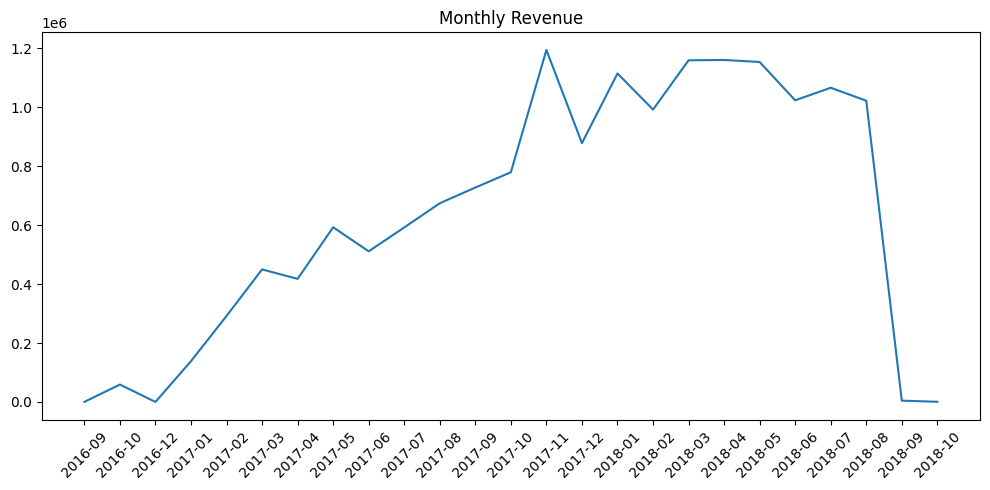

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
)

sales = orders.merge(
    payments,
    on='order_id'
)

monthly_revenue = (
    sales.groupby('month')['payment_value']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['month'].astype(str),
    monthly_revenue['payment_value']
)

plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.tight_layout()
plt.show()

growth = (
    monthly_revenue['payment_value'].iloc[-1] /
    monthly_revenue['payment_value'].iloc[0] - 1
)

print(f"Рост выручки: {growth:.1%}")

Рост рассчитан как изменение между первым и последним месяцем анализируемого периода.

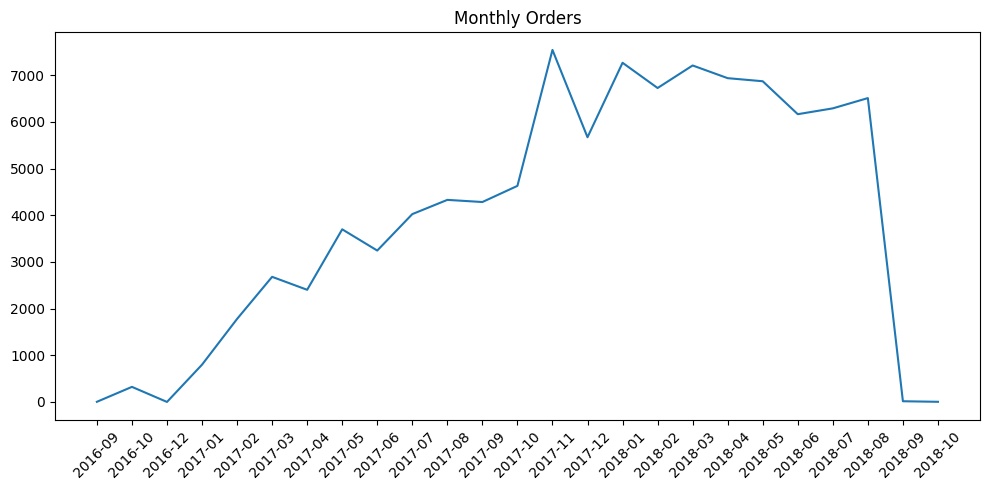

In [ ]:
monthly_orders = (
    orders.groupby('month')['order_id']
    .nunique()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders['month'].astype(str),
    monthly_orders['order_id']
)

plt.xticks(rotation=45)
plt.title('Monthly Orders')
plt.tight_layout()
plt.show()

orders_growth = (
    monthly_orders['order_id'].iloc[-1] /
    monthly_orders['order_id'].iloc[0] - 1
)

print(f"Рост заказов: {orders_growth:.1%}")

### Business Interpretation

Наблюдается положительная динамика:

- объём заказов увеличивается к концу периода;
- выручка растёт вместе с увеличением количества транзакций;
- платформа показывает расширение пользовательской активности.

При этом рост сопровождается низким уровнем повторных покупок, что требует отдельного анализа удержания.

## Customer Repeat Behavior

In [6]:
customer_orders = (
    orders
    .merge(
        customers,
        on='customer_id'
    )
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

print('orders_1_purchase: ', (customer_orders == 1).sum())

print('orders_purchases: ', (customer_orders > 1).sum())

repeat_rate = (
    (customer_orders > 1).mean() * 100
)
print('repeat_rate: ', repeat_rate)

orders_1_purchase:  93099
orders_purchases:  2997
repeat_rate:  3.1187562437562435


### Business Interpretation

Repeat Purchase Rate составляет около 3.1%.

Это означает, что только небольшая часть клиентов совершает более одной покупки.

## Product Category Analysis

Для оценки вклада категорий рассчитываются:

- количество заказов;
- выручка;
- количество проданных товаров.

In [ ]:
items_products = (
    items
    .merge(
        products,
        on='product_id',
        how='left'
    )
    .merge(
        categories,
        on='product_category_name',
        how='left'
    )
)

category_stats = (
    items_products
    .groupby('product_category_name_english')
    .agg(
        orders_count=('order_id','nunique'),
        revenue=('price','sum'),
        items_sold=('product_id','count')
    )
    .reset_index()
)

top_orders = category_stats.nlargest(10, 'orders_count')

top_revenue = category_stats.nlargest(10, 'revenue')

print("ТОП-10 КАТЕГОРИЙ ПО КОЛИЧЕСТВУ ЗАКАЗОВ:")
print(top_orders[['product_category_name_english', 'orders_count', 'revenue', 'items_sold']])
print("\n")

print("ТОП-10 КАТЕГОРИЙ ПО ВЫРУЧКЕ:")
print(top_revenue[['product_category_name_english', 'revenue', 'orders_count', 'items_sold']])



ТОП-10 КАТЕГОРИЙ ПО КОЛИЧЕСТВУ ЗАКАЗОВ:
   product_category_name_english  orders_count     revenue  items_sold
7                 bed_bath_table          9417  1036988.68       11115
43                 health_beauty          8836  1258681.34        9670
65                sports_leisure          7720   988048.97        8641
15         computers_accessories          6689   911954.32        7827
39               furniture_decor          6449   729762.49        8334
49                    housewares          5884   632248.66        6964
70                 watches_gifts          5624  1205005.68        5991
68                     telephony          4199   323667.53        4545
5                           auto          3897   592720.11        4235
69                          toys          3886   483946.60        4117


ТОП-10 КАТЕГОРИЙ ПО ВЫРУЧКЕ:
   product_category_name_english     revenue  orders_count  items_sold
43                 health_beauty  1258681.34          8836        9670
70    

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    top_revenue['product_category_name_english'],
    top_revenue['revenue']
)

plt.xticks(rotation=45)
plt.title("Top categories by revenue")
plt.show()

## Category Analysis

Наиболее значимые категории по объёму продаж:

- health_beauty;
- bed_bath_table;
- sports_leisure.


Категории-лидеры определяются по стоимости проданных товаров и количеству заказов.

Стоимость категорий рассчитана на основе поля `price`.

# Business Insights

1. Платформа обработала 99 441 заказ от 96 096 уникальных клиентов.
Общий объём платежей через платформу составил около 16.0M BRL.

2. Средний чек находится на уровне 161 BRL, что характеризует текущий уровень стоимости заказа.

3. В течение анализируемого периода наблюдается рост количества заказов и выручки, что говорит о расширении активности пользователей платформы.

4. Repeat Purchase Rate составляет около 3.1%.
Большинство пользователей совершает только одну покупку, поэтому основной потенциал роста связан с увеличением удержания существующих клиентов.

5. Основные категории по стоимости проданных товаров:
- health_beauty;
- bed_bath_table;
- sports_leisure.

Эти категории формируют значительную часть товарной выручки и могут использоваться как приоритетные направления для маркетинговых активностей и развития ассортимента.